
# Homework 6 — Measuring Tone in Financial Text

## Overview
In this assignment, you will:
1. Select a financial or economic text of your choice and load it into Python.
2. Use regular expressions to extract specific patterns from the text.
3. Preprocess the text (cleaning, tokenization, stopword removal, lemmatization) and visualize word frequencies.
4. Score the document using the **Loughran–McDonald (LM)** lexicon.
5. Score the document using **VADER** and compare the two methods.

The core question motivating this assignment is drawn from Loughran & McDonald (2011, *Journal of Finance*):

> *"Word lists developed for other disciplines misclassify common words in financial text... we show that almost three-fourths of the words identified as negative by the Harvard Dictionary are not typically negative in a financial context."*

https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1540-6261.2010.01625.x



## 1. Setup

Run the cell below to install packages if needed.
On Google Colab, most are pre-installed.


In [4]:

# If needed, uncomment to install
%pip install nltk pdfplumber --quiet
%pip install nltk --quiet

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
for corpus in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'vader_lexicon']:
    nltk.download(corpus, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 140


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



## 2. Choose Your Text

Select **one** source (you may change these — just explain your choice in Section 6).  
Aim for roughly **500–3,000 words** of continuous prose.

| Option | Suggested Text | Where to Find It |
|--------|---------------|------------------|
| A *(recommended)* | Earnings call transcript — CEO/CFO prepared remarks for any S&P 500 company | seekingalpha.com, motleyfool.com, or the company's investor relations page |
| B | Federal Reserve FOMC statement — pick any single meeting | federalreserve.gov/monetarypolicy/fomccalendars.htm |
| C | SEC 10-K Item 1A (Risk Factors) or Item 7 (MD&A) for any public firm | sec.gov/cgi-bin/browse-edgar |
| D | IMF or World Bank country economic outlook excerpt | imf.org/en/Publications/WEO |
| E | Warren Buffett's annual letter to Berkshire shareholders (any year) | berkshirehathaway.com/letters/letters.html |

Paste or save the text as a `.txt` file, place it in your working directory (or Google Drive), then load it in the cell below.


In [5]:
from pathlib import Path

# Resolve absolute path so it works regardless of where the kernel was launched
NOTEBOOK_DIR = Path().resolve()

# Google Drive (Colab):
# file_path = Path('/content/drive/MyDrive/Fin798/NikeConfQ32026.txt')
file_path = NOTEBOOK_DIR / 'NikeConfQ32026.txt'
print(f"Looking for: {file_path}")

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    print(f"✅ Loaded ({len(text):,} characters)")
except FileNotFoundError:
    print(f"❌ Not found — place NikeConfQ32026.txt in:\n   {NOTEBOOK_DIR}")

Looking for: C:\Users\laris\Downloads\NikeConfQ32026.txt
✅ Loaded (51,693 characters)



## 3. Regular Expressions

Use `re` to search your text for patterns relevant to your document.

- Write a regex that finds **at least two** financially meaningful terms or patterns (e.g., a keyword like *sold*, a word family like *sell / sold / selling*, or a numeric pattern like a dollar amount).
- For each pattern: print the total number of matches and display up to 5 matches with ~60 characters of surrounding context.


In [27]:
# Extended: sold | sell | selling
pat = re.compile(r"\b(sell|sold|selling)\b", re.I)
matches = list(pat.finditer(text))
print(f"Occurrences of sell/sold/selling: {len(matches)}")
for m in matches:
    print("  …", text[max(0,m.start()-60):m.end()+60].strip(), "…")

    pat = re.compile(r"\bmillion\b", re.I)
matches = list(pat.finditer(text))
print(f"Occurrences of 'million': {len(matches)}")
for m in matches:
    print("  …", text[max(0,m.start()-60):m.end()+60].strip(), "…")

Occurrences of sell/sold/selling: 29
  … ar away distractions pre and post competition. The Mind 001 sold out in all geographies. We responded by doubling production …
  … ekend, which connected us to consumers and drove full-price sell-throughs while deepening our wholesale partnerships in Los …
  … best innovation stories, all with the goal of accelerating sell-through. If Running shows what our Sport Offense can do, No …
  … ortswear styles.
A great example this quarter is the strong sell-through we drove around the globe with a more thoughtful ap …
  … s are growing, and we are taking back shelf space. However, sell-through trends are not yet where we want them to be. Despit …
  … ent actions with existing partners in the prior year. While sell-through has been below plan, sell-through improved in Febru …
  … in the prior year. While sell-through has been below plan, sell-through improved in February, and we drove positive growth …
  … t growth in running. Sportswear was down doubl


## 4. Text Preprocessing & Word Frequency

Clean the raw text and build a token list, then plot the top 20 words **before** and **after**
stopword removal (two separate bar charts, as shown in lecture).

Your pipeline should:
- Lowercase and remove non-alphabetic characters
- Tokenize by splitting on whitespace
- Remove stopwords and short tokens (length ≤ 2)
- Apply lemmatization
- Print token counts at each stage


In [16]:
PATTERNS = {
    'Dollar amounts':      r'\$[\d,]+(?:\.\d+)?(?:\s*(?:billion|million|trillion))?',
    'Percentages':         r'\b[\d,]+(?:\.\d+)?\s*%',
    'Year-over-year':      r'\d+(?:\.\d+)?%\s+year[- ]over[- ]year',
    'EPS mentions':        r'EPS[^.\n]{0,80}',
    'Record mentions':     r'(?:all[- ]time|june|quarterly)\s+record[^.\n]{0,60}',
    'Tariff mentions':     r'tariff[^.\n]{0,80}',
}

for label, pattern in PATTERNS.items():
    matches = re.findall(pattern, text, re.IGNORECASE)
    print(f"\n{label} ({len(matches)} found)")
    for m in matches[:3]:
        print(f"  • {m.strip()}")


Dollar amounts (6 found)
  • $4 billion
  • $0.35
  • $230 million

Percentages (47 found)
  • 20%
  • 200%
  • 3%

Year-over-year (0 found)

EPS mentions (3 found)
  • eps this quarter to bring the brand back to a healthy business
  • eps to reset our cost base to improve NIKE's long-term profitability
  • EPS through the February quarter? And then should we think about the May quarter of

Record mentions (0 found)

Tariff mentions (8 found)
  • tariffs in North America
  • tariffs
  • tariffs


In [17]:
# Segment-level revenue table
seg_pat = re.compile(
    r'(iPhone|Mac|iPad|Services|Wearables)[^.]*?\$(\d+(?:\.\d+)?)\s*billion[^.]*?'
    r'(up|down)\s*(\d+(?:\.\d+)?)%[^.]*?year', re.IGNORECASE)

print(f"{'Segment':<14} {'Revenue ($B)':>12} {'Dir':>5} {'YoY%':>6}")
print("─" * 42)
for m in seg_pat.finditer(text):
    seg, rev, d, pct = m.groups()
    print(f"{seg:<14} {rev:>12} {d:>5} {pct:>5}%")

Segment        Revenue ($B)   Dir   YoY%
──────────────────────────────────────────


In [18]:
clean = re.sub(r"[^a-z\s]", " ", text.lower())
clean = re.sub(r"\s+",      " ", clean).strip()
tokens = clean.split()

print(f"Raw chars  : {len(text):,}")
print(f"Clean chars: {len(clean):,}")
print(f"Tokens     : {len(tokens):,}")
print(f"Sample     : {tokens[:15]}")

Raw chars  : 51,693
Clean chars: 50,250
Tokens     : 8,830
Sample     : ['conference', 'call', 'participants', 'lorraine', 'maikis', 'bofa', 'securities', 'research', 'division', 'adrienne', 'yih', 'tennant', 'barclays', 'bank', 'plc']


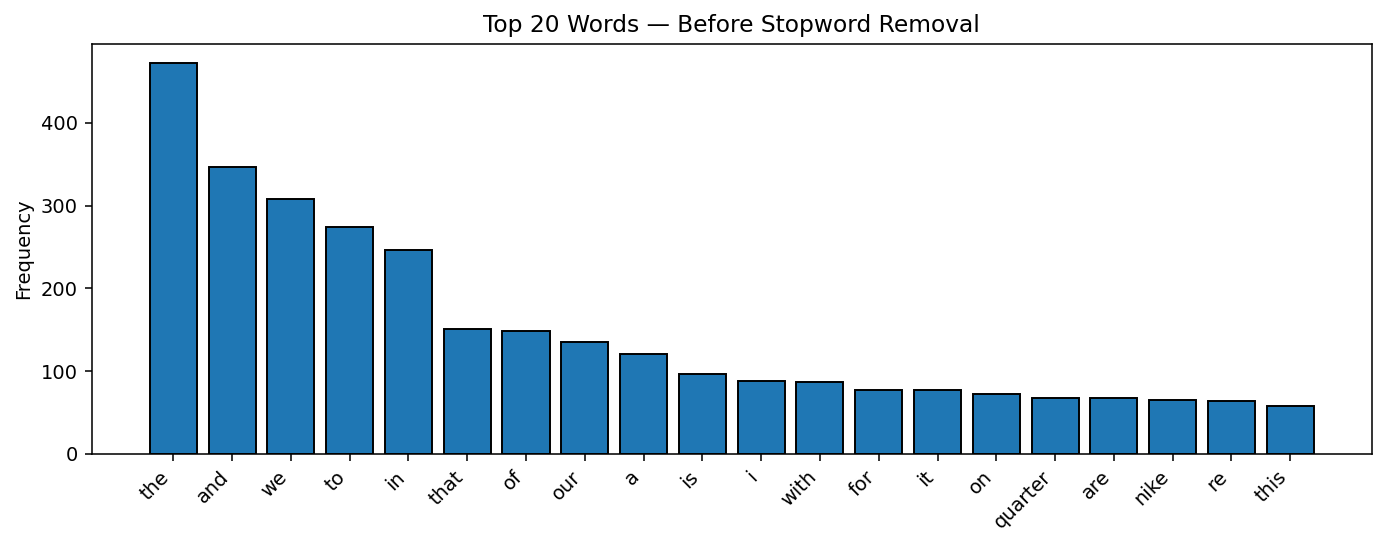

In [19]:
freq_raw = Counter(tokens).most_common(20)
words, counts = zip(*freq_raw)
plt.bar(words, counts, edgecolor='black')
plt.title('Top 20 Words — Before Stopword Removal')
plt.ylabel('Frequency'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

After stopword removal : 4,515  unique: 1308
After lemmatisation    : 4,515  unique: 1047


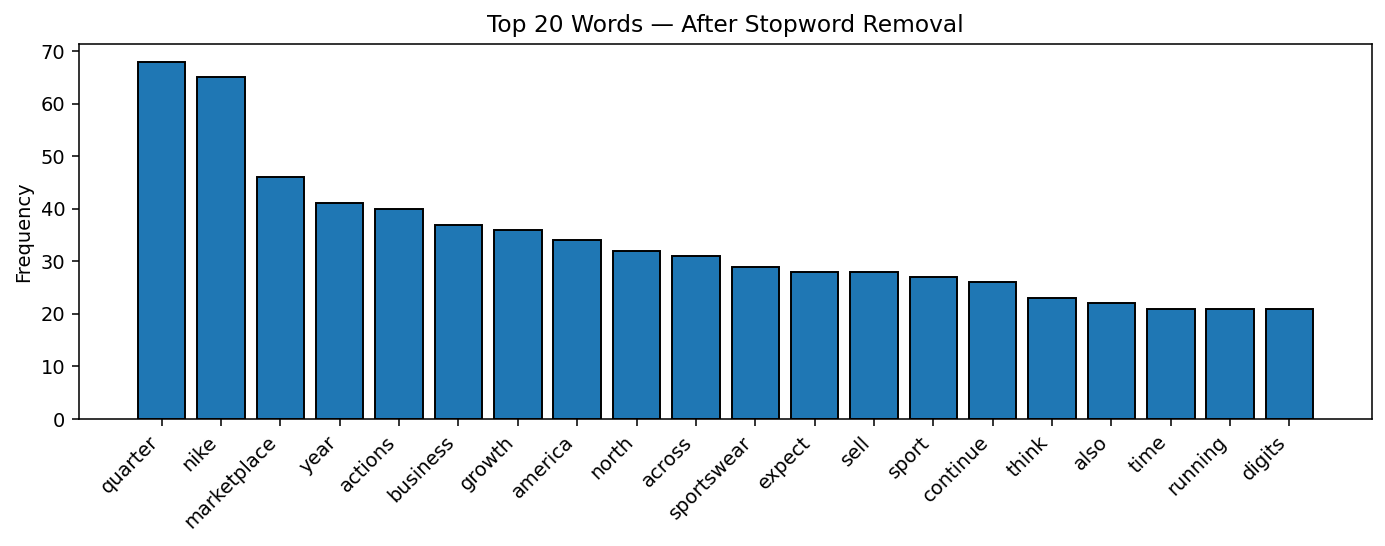

In [20]:
stop = set(stopwords.words('english'))
lem  = WordNetLemmatizer()

tokens_ns  = [t for t in tokens  if t not in stop and len(t) > 2]
tokens_lem = [lem.lemmatize(lem.lemmatize(t, pos='v'), pos='n') for t in tokens_ns]

print(f"After stopword removal : {len(tokens_ns):,}  unique: {len(set(tokens_ns))}")
print(f"After lemmatisation    : {len(tokens_lem):,}  unique: {len(set(tokens_lem))}")

freq_ns = Counter(tokens_ns).most_common(20)
w, c = zip(*freq_ns)
plt.bar(w, c, edgecolor='black')
plt.title('Top 20 Words — After Stopword Removal')
plt.ylabel('Frequency'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

After lemmatisation   : 4,515  unique: 1047
After domain filter   : 443  unique: 66


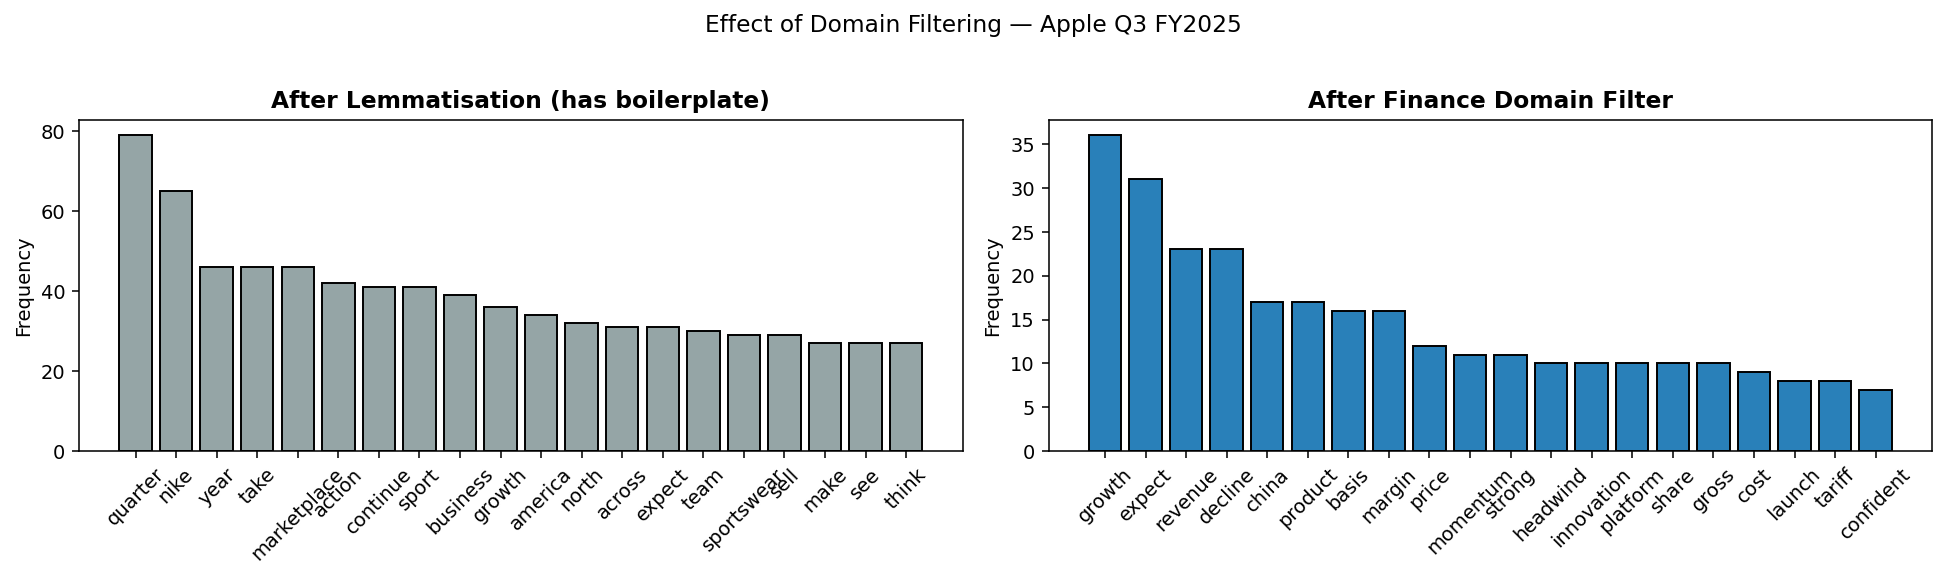

In [21]:
EARNINGS_BOILERPLATE = {
    # Greetings & procedural
    'good','afternoon','morning','welcome','thank','thanks','please',
    'note','today','call','conference','join','begin','open','recording',
    # Speaker roles
    'chief','executive','officer','director','investor','relation',
    'president','vice','senior','svp','cfo','ceo',
    # Company names — update for each company you analyse
    'apple','tim','cook','kevin','parekh','suhasini','chandramouli',
    # Temporal boilerplate
    'quarter','quarterly','fiscal','year','annual','month',
    'january','february','march','april','june','july','august',
    'september','october','november','december',
    # Generic filler
    'company','business','result','report','forward','look','statement',
    'think','know','just','really','get','make','also','well',
    'want','see','come','back','right','like','say','give',
}

FINANCE_VOCAB = {
    # Revenue & growth
    'revenue','sale','growth','record','increase','decrease','decline',
    'rise','fall','gain','expand','accelerate','outperform','underperform',
    # Profitability
    'profit','earnings','margin','ebitda','net','gross','operating',
    'income','expense','cost','price','premium','discount',
    # Financial metrics
    'eps','return','yield','valuation','billion','million','percent','basis',
    # Capital allocation
    'cash','flow','capital','debt','equity','leverage','asset','liability',
    'dividend','buyback','repurchase','invest','capex','opex','fund',
    # Markets & products
    'market','share','segment','product','service','demand','supply',
    'customer','user','subscriber','platform','ecosystem','device','upgrade',
    # Strategy
    'strategy','acquisition','merger','innovation','development','launch',
    'scale','efficiency','productivity','transform',
    # Risk & macro
    'risk','uncertainty','challenge','headwind','tailwind',
    'inflation','interest','rate','tariff','regulation','volatility',
    'exposure','hedge','currency',
    # Guidance
    'guidance','forecast','outlook','estimate','expect','target','momentum',
    # Geography
    'china','usa','europe','india','asia','international','emerging','global',
    # Tone words
    'strong','weak','positive','negative','confident','cautious',
    'optimistic','concern','difficult','opportunity','impressive',
    'exceptional','disappointing','challenging','robust','solid',
    # Apple-specific — swap for your company
    'iphone','mac','ipad','silicon','intelligence','privacy','subscription',
}

tokens_fin = [t for t in tokens_lem
              if t not in EARNINGS_BOILERPLATE and t in FINANCE_VOCAB]

print(f"After lemmatisation   : {len(tokens_lem):,}  unique: {len(set(tokens_lem))}")
print(f"After domain filter   : {len(tokens_fin):,}  unique: {len(set(tokens_fin))}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, tkns, title, color in [
    (axes[0], tokens_lem, 'After Lemmatisation (has boilerplate)', '#95a5a6'),
    (axes[1], tokens_fin, 'After Finance Domain Filter',           '#2980b9'),
]:
    top = Counter(tkns).most_common(20)
    if top:
        w2, c2 = zip(*top)
        ax.bar(w2, c2, edgecolor='black', color=color)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Frequency'); ax.tick_params(axis='x', rotation=45)
plt.suptitle('Effect of Domain Filtering — Apple Q3 FY2025', y=1.02)
plt.tight_layout(); plt.show()


## 5. Sentiment Scoring

Score your document with both methods covered in lecture.

### 5a. Loughran–McDonald Lexicon

Use the LM Master Dictionary CSV (available on Blackboard / Google Drive).

- Build a `words2weights` dictionary mapping each word to `+1` (positive) or `−1` (negative).
- For each matched word, print the word and its contribution to the total score.
- Compute and print the raw score, then normalize by document length.

### 5b. VADER

Use `SentimentIntensityAnalyzer` from NLTK.

- Compute and print the polarity scores (`neg`, `neu`, `pos`, `compound`) for the whole document.


In [22]:
from pathlib import Path
NOTEBOOK_DIR = Path().resolve()

# Google Drive (Colab):
# LM_PATH = Path('/content/drive/MyDrive/Fin798/Loughran-McDonald_MasterDictionary_1993-2024.csv')
LM_PATH = NOTEBOOK_DIR / 'Loughran-McDonald_MasterDictionary_1993-2024.csv'
print(f"Looking for: {LM_PATH}")

if not LM_PATH.exists():
    print(f"❌ Not found — place the LM CSV in:\n   {NOTEBOOK_DIR}")
else:
    lm = pd.read_csv(LM_PATH)
    lm.columns = [c.strip().upper() for c in lm.columns]
    for col in ['POSITIVE','NEGATIVE','UNCERTAINTY','LITIGIOUS','STRONG_MODAL','CONSTRAINING']:
        lm[col] = lm[col].astype(int)
    print(f"✅ LM rows: {len(lm):,} | columns: {list(lm.columns)[:12]}")
    print(lm.head(3).to_string())

Looking for: C:\Users\laris\Downloads\Loughran-McDonald_MasterDictionary_1993-2024.csv
✅ LM rows: 86,553 | columns: ['WORD', 'SEQ_NUM', 'WORD COUNT', 'WORD PROPORTION', 'AVERAGE PROPORTION', 'STD DEV', 'DOC COUNT', 'NEGATIVE', 'POSITIVE', 'UNCERTAINTY', 'LITIGIOUS', 'STRONG_MODAL']
        WORD  SEQ_NUM  WORD COUNT  WORD PROPORTION  AVERAGE PROPORTION  STD DEV  DOC COUNT  NEGATIVE  POSITIVE  UNCERTAINTY  LITIGIOUS  STRONG_MODAL  WEAK_MODAL  CONSTRAINING  COMPLEXITY  SYLLABLES     SOURCE
0   AARDVARK        1         755         0.000000            0.000000 0.000004        140         0         0            0          0             0           0             0           0          2  12of12inf
1  AARDVARKS        2           3         0.000000            0.000000 0.000000          1         0         0            0          0             0           0             0           0          2  12of12inf
2      ABACI        3           9         0.000000            0.000000 0.000000          7

In [23]:
# Build sentiment lexicon — vectorised (avoids numpy 2.0 scalar comparison errors)
pos_mask = lm['POSITIVE'] != 0
neg_mask = lm['NEGATIVE'] != 0

lm_scored          = lm[['WORD']].copy()
lm_scored['score'] = pos_mask.astype(float) - neg_mask.astype(float)
lm_scored          = lm_scored[lm_scored['score'] != 0]
lm_scored['word']  = lm_scored['WORD'].str.lower()

words2weights = dict(zip(lm_scored['word'], lm_scored['score']))
n_pos = sum(1 for v in words2weights.values() if v > 0)
n_neg = sum(1 for v in words2weights.values() if v < 0)
print(f"Lexicon: {len(words2weights):,} words  ({n_pos} positive, {n_neg} negative)")

Lexicon: 2,709 words  (354 positive, 2355 negative)


In [24]:
# Per-word sentiment contribution
for word, weight in words2weights.items():
    hits = re.findall(r'\b' + word + r'\b', text, re.IGNORECASE)
    if hits:
        print(f"{word}: {len(hits) * weight:+.1f}")

able: +4.0
against: -3.0
beautiful: +1.0
benefit: +2.0
best: +2.0
better: +3.0
challenges: -4.0
challenging: -1.0
closeout: -3.0
confident: +7.0
conviction: -1.0
creative: +2.0
critical: -2.0
critically: -3.0
decline: -1.0
declined: -16.0
declines: -5.0
declining: -1.0
deliberate: -2.0
deliberately: -1.0
despite: +5.0
disruption: -4.0
distinction: +1.0
distractions: -1.0
easy: +1.0
effective: +1.0
encouraged: +3.0
excited: +5.0
excitement: +2.0
force: -1.0
gain: +1.0
gains: +1.0
good: +4.0
great: +2.0
greater: +15.0
greatest: +1.0
greatness: +1.0
improve: +4.0
improved: +4.0
improvement: +8.0
improvements: +1.0
improving: +4.0
incredibly: +2.0
inflicted: -1.0
innovate: +1.0
innovation: +10.0
innovative: +4.0
intentional: -2.0
lack: -1.0
leadership: +3.0
leading: +3.0
liquidation: -3.0
markdowns: -2.0
negative: -3.0
opportunities: +2.0
opportunity: +4.0
pleased: +5.0
positive: +7.0
positively: +1.0
problems: -1.0
profitability: +6.0
profitable: +4.0
progress: +13.0
progressing: +1.0
que

In [25]:
# Aggregate document score
score = sum(
    len(re.findall(r'\b' + w + r'\b', text, re.IGNORECASE)) * v
    for w, v in words2weights.items()
)
print(f"Raw score       : {score:.1f}")
print(f"Per-word score  : {score / max(len(tokens_lem), 1):.5f}")

Raw score       : 110.0
Per-word score  : 0.02436


In [26]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()
print("VADER:", vader.polarity_scores(text))

VADER: {'neg': 0.025, 'neu': 0.819, 'pos': 0.156, 'compound': 1.0}



## 6. Write-Up — Discussion Prompts

- **Text Selection:** Why did you choose this document? What tone did you expect before running any analysis?
- **Regex Findings:** What did your regex patterns reveal about the document? Were any results surprising?
- **Word Frequency:** What does the top-20 chart after stopword removal tell you about the main themes of the document?
- **LM vs. VADER:** Do the two methods agree on the overall direction (positive vs. negative) of your document? If they disagree, which specific words might explain the gap?
- **The Loughran–McDonald Argument:** Can you find at least one word in your text that a general-purpose dictionary would score incorrectly in a financial context? What does the LM dictionary say about it?


1) I chose Nike's Q32026 transcript because I currently have investments in their stock and have been hearing a lot of negative sentiments around Nike from WSJ and other financial news sources. I wanted to see if the negative analysis of other platforms matched the .txt transcript sentiment
2) The Regex patters revealed that a lot of sale expectations and "sell-ins" were not met for the quarter and that they need to do some major re-strategizing in order to bring back sales with all of the current economic hurdles Nike is facing.
3) After stopword removal, the top-20 words shows me that the company is focusing mainly on future goals and predictions of growth (likely because they've been doing so poorly the past year), along with foucusing on domestic sales as opposed to global (probably because of the implement effects from tarrifs)
4) Surprisingly, yes, they both agree that there is a slightly positive tone to the overall sentiment, which is interesting because I believe the tone should be coming across and slightly if not moderately negative. 
5) There are a number of words in Nike's transcript that likely scored incorrectly because of its financial context. For example, "despite" is marked in LM as a positive word. After reading through Nike's transcripts, there are a few iterations where despite is used to emphasize a negative effect on the company, meaning it should technically have a negative sentiment attached to it. 